# ITO5202 Data processing for big data

##  Activity: Machine Learning with Spark (Classification Using Decision Tree, Random Forest,  and Logistic Regression)

Last week we learnt about basics of machine learning with Apache Spark. **``MLlib``** is Apache Spark's scalable machine learning library. Its goal is to make practical machine learning scalable and easy. At a high level, it provides tools such as:

- ML Algorithms: common learning algorithms such as classification, regression, clustering, and collaborative filtering
- Featurization: feature extraction, transformation, dimensionality reduction, and selection
- Pipelines: tools for constructing, evaluating, and tuning ML Pipelines
- Persistence: saving and load algorithms, models, and Pipelines
- Utilities: linear algebra, statistics, data handling, etc.

We looked into transformers, estimators and machine learning pipeline in the last weeks tutorial activity.

This week we have learnt about different classification algorithms in the lecture. We will look into how to use the different popular family of classification and regression methods; Decision Trees and Random forests.

## Table of Contents

* [Bank case study: Will the client subscribe?](#one)
* [Data Loading and Preparation](#data-preparation)
* [Feature Engineering](#feature-engineering)
    * [StringIndexer](#feature-engineering)
    * [OneHotEncoder](#feature-engineering)
    * [VectorAssembler](#feature-engineering)
* [Pipeline API](#pipeline)
* [Train/Test Split](#train-test)
* [ML Classification Models](#models)
    * [Decision Tree](#dt)
    * [Random Forest](#rf)        
    * [Logistic Regression](#lr)    
* [Model Evaluation](#model-evaluation)
    * [Confusion Matrix](#confusion-matrix)
    * [Area Under the Curve](#roc)    
    * [Visualizing ROC Curve](#roc-viz)
* [Lab Tasks](#lab-task-1)
    * [Lab Task 1](#lab-task-1)
    * [Lab Task 2](#lab-task-2)
    * [Lab Task 3](#lab-task-3)
    * [Lab Task 4](#lab-task-4)
    * [Lab Task 5](#lab-task-5)
* [Challenge Tasks](#challenge-task)
    * [Challenge Task 1](#challenge-task)
    

## Bank case study: Will the client subscribe? <a class="anchor" id="one"></a>
<hr/>

The data was used to direct marketing campaigns of a banking institution. The marketing campaigns were based on phone calls. The classification goal is to predict whether the client will subscribe (1/0) to a term deposit.

### **Attributes**

1. age (numeric)
2. job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3. marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4. education (categorical: 'primary', 'secondary', 'tertiary', 'unknown')
5. default: has credit in default? (categorical: 'no','yes','unknown')
6. balance : bank balance
7. housing: has housing loan? (categorical: 'no','yes','unknown')
8. loan: has personal loan? (categorical: 'no','yes','unknown')

### Related with the last contact of the current campaign:
9. contact: contact communication type (categorical: 'cellular','telephone','unknown')
10. day: last contact day of the week (numerical: 1,2,...28,29,30)
1. month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
12. duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

### Other attributes:
12. campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13. pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14. previous: number of contacts performed before this campaign and for this client (numeric)
15. poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success','unknown')

### Output variable (desired target):
16. deposit - has the client subscribed a term deposit? (binary: 'yes','no')

<a class="anchor" id="lab-task-1"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#FF5555">1. Lab Task: </strong> 

Complete the following steps for the initial part to get the data ready for the Classification Algorithms.

 1. **Loading data:** Load the <code>bank.csv</code> file using spark session
 2. **Prepare the data :** Prepare data for machine learning and preprocess the data according to the algorithm for training. 
 3. **Feature Engineering:** Use <code>StringIndexer</code>, <code>OneHotEncoder</code> and <code>Vector Assembler</code> to transform the dataset into <em>features</em> and <em>label</em> columns. 
 4. **Pipeline API :** Assemble the above steps of transformation into a <code>Pipeline</code>. Use the pipeline to <strong>transform</strong> the data.
 5. **Train/Test Split :** For the transformed data, create a <strong>train/test</strong> split of <strong>80%/20%</strong>.
</div>

### Step 1: Data Loading and Preparation <a class="anchor" name="data-preparation"></a> 

In this step, you can do some data exploration like: 
1. See some sample data, check the schema
2. Check the statistics of the numerical columns in the dataset
3. Target Variable Distribution, what are the number of instances the target variable has?
4. Check if the dataframe contains null values?
5. Separate the numerical and non-numerical columns to apply feature engineering

In [1]:
#Write your code here


from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when

# Create Spark session
spark = SparkSession.builder \
    .appName("Bank Marketing Classification") \
    .getOrCreate()

# Load bank.csv
df = spark.read.csv(
    "bank.csv",
    header=True,
    inferSchema=True
)

# Show some sample records
df.show(10, truncate=False)

# Check the schema
df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/06 10:27:52 WARN Utils: Your hostname, Stefans-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.104 instead (on interface en0)
26/09/06 10:27:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/opt/anaconda3/envs/ITO5202/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/06 10:27:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/06 10:27:53 WARN Utils: Service '

+---+----------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
|age|job       |marital |education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|deposit|
+---+----------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
|59 |admin.    |married |secondary|no     |2343   |yes    |no  |unknown|5  |may  |1042    |1       |-1   |0       |unknown |yes    |
|56 |admin.    |married |secondary|no     |45     |no     |no  |unknown|5  |may  |1467    |1       |-1   |0       |unknown |yes    |
|41 |technician|married |secondary|no     |1270   |yes    |no  |unknown|5  |may  |1389    |1       |-1   |0       |unknown |yes    |
|55 |services  |married |secondary|no     |2476   |yes    |no  |unknown|5  |may  |579     |1       |-1   |0       |unknown |yes    |
|54 |admin.    |married |tertiary |no     |184    |no     |no  |unkno

In [2]:
# Display summary statistics for numerical columns
df.describe().show()

26/09/06 10:28:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+-------+--------+---------+-------+------------------+-------+-----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+-------+
|summary|               age|    job| marital|education|default|           balance|housing| loan| contact|               day|month|          duration|          campaign|             pdays|          previous|poutcome|deposit|
+-------+------------------+-------+--------+---------+-------+------------------+-------+-----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+-------+
|  count|             11162|  11162|   11162|    11162|  11162|             11162|  11162|11162|   11162|             11162|11162|             11162|             11162|             11162|             11162|   11162|  11162|
|   mean|41.231947679627304|   NULL|    NULL|     NULL|   NULL|1528.5385235620856|   NULL| NULL|    NULL

In [4]:
numerical_cols = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

df.select(numerical_cols).summary().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|               age|           balance|               day|          duration|          campaign|             pdays|          previous|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|             11162|             11162|             11162|             11162|             11162|             11162|             11162|
|   mean|41.231947679627304|1528.5385235620856|15.658036194230425|371.99381831213043| 2.508421429851281| 51.33040673714388|0.8325568894463358|
| stddev|11.913369192215518| 3225.413325946149| 8.420739541006462|347.12838571630687|2.7220771816614824|108.75828197197717| 2.292007218670508|
|    min|                18|             -6847|                 1|                 2|                 1|                -1|                 0|

In [7]:


df.groupBy("deposit") \
    .count() \
    .withColumn(
        "percentage",
        col("count") / total * 100
    ) \
    .show()

+-------+-----+-----------------+
|deposit|count|       percentage|
+-------+-----+-----------------+
|     no| 5873|52.61601863465329|
|    yes| 5289|47.38398136534671|
+-------+-----+-----------------+



In [8]:
null_counts = df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in df.columns
])

null_counts.show()

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|deposit|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|      0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+



In [9]:
numerical_cols = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

target_col = "deposit"

In [10]:
# Numerical columns
numerical_cols = [
    field.name
    for field in df.schema.fields
    if field.dataType.typeName() in ["integer", "long", "double", "float"]
    and field.name != "deposit"
]

# Categorical columns
categorical_cols = [
    field.name
    for field in df.schema.fields
    if field.dataType.typeName() == "string"
    and field.name != "deposit"
]

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Step 2: Feature Engineering <a class="anchor" name="feature-engineering"></a> 
<strong>Hint :</strong> Use all the features, separate the numerical and non-numerical features to simplify the Feature Engineering process. For the <strong style="color:red"> target variable, make sure 1 is for Yes and 0 is for No</strong> while converting it to numeric representation.

In [11]:
#Write your code here
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import when, col

df = df.withColumn(
    "label",
    when(col("deposit") == "yes", 1.0)
    .when(col("deposit") == "no", 0.0)
)

# Check the conversion
df.select("deposit", "label").show(10)

+-------+-----+
|deposit|label|
+-------+-----+
|    yes|  1.0|
|    yes|  1.0|
|    yes|  1.0|
|    yes|  1.0|
|    yes|  1.0|
|    yes|  1.0|
|    yes|  1.0|
|    yes|  1.0|
|    yes|  1.0|
|    yes|  1.0|
+-------+-----+
only showing top 10 rows


In [12]:
indexers = [
    StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )
    for col_name in categorical_cols
]

In [13]:
indexed_cols = [col_name + "_index" for col_name in categorical_cols]

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=[col_name + "_encoded" for col_name in categorical_cols]
)

In [14]:
encoded_cols = [
    col_name + "_encoded"
    for col_name in categorical_cols
]

assembler_inputs = numerical_cols + encoded_cols

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features"
)

### Step 3: Pipeline API <a class="anchor" name="pipeline"></a> 

In [15]:
#Write your code here
pipeline = Pipeline(
    stages=indexers + [encoder, assembler]
)

pipeline_model = pipeline.fit(df)

df_transformed = pipeline_model.transform(df)

In [16]:
df_transformed.select(
    "deposit",
    "label",
    "features"
).show(10, truncate=False)

+-------+-----+-------------------------------------------------------------------------------------------------------------------+
|deposit|label|features                                                                                                           |
+-------+-----+-------------------------------------------------------------------------------------------------------------------+
|yes    |1.0  |(51,[0,1,2,3,4,5,10,19,22,26,29,30,33,35,47],[59.0,2343.0,5.0,1042.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])|
|yes    |1.0  |(51,[0,1,2,3,4,5,10,19,22,26,28,30,33,35,47],[56.0,45.0,5.0,1467.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])  |
|yes    |1.0  |(51,[0,1,2,3,4,5,9,19,22,26,29,30,33,35,47],[41.0,1270.0,5.0,1389.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0]) |
|yes    |1.0  |(51,[0,1,2,3,4,5,11,19,22,26,29,30,33,35,47],[55.0,2476.0,5.0,579.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0]) |
|yes    |1.0  |(51,[0,1,2,3,4,5,10,19,23,26,28,30,33,35,47],[54.0,184.0,5.0,

In [17]:
df_transformed.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)
 |-- label: double (nullable = true)
 |-- job_index: double (nullable = false)
 |-- marital_index: double (nullable = false)
 |-- education_index: double (nullable = false)
 |-- default_index: double (nullable = false)
 |-- housing_index: double (nullable = false)
 |-- loan_index: double (nullable = false)
 |-- contact_index: double (nu

### Step 4: Train/Test Split <a class="anchor" name="train-test"></a> 
<strong>Hint : </strong> Use <code>seed</code> while splitting data to identify different sets of train/test splits.

In [18]:
#Write your code here

# Split the transformed data into 80% training and 20% testing
train_data, test_data = df_transformed.randomSplit(
    [0.8, 0.2],
    seed=42
)

# Check the number of records in each dataset
print("Training set:", train_data.count())
print("Test set:", test_data.count())

# Check the schema
print("\nTraining data schema:")
train_data.printSchema()

Training set: 8998
Test set: 2164

Training data schema:
root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)
 |-- label: double (nullable = true)
 |-- job_index: double (nullable = false)
 |-- marital_index: double (nullable = false)
 |-- education_index: double (nullable = false)
 |-- default_index: double (nullable = false)
 |-- housing_index: double (nullable = false)
 |-- loan_index:

In [19]:
print("Training set target distribution:")
train_data.groupBy("label").count().show()

print("Test set target distribution:")
test_data.groupBy("label").count().show()

Training set target distribution:
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 4722|
|  1.0| 4276|
+-----+-----+

Test set target distribution:
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 1151|
|  1.0| 1013|
+-----+-----+



## ML Classification Models <a class="anchor" name="models"></a>
<hr />

### Decision Tree <a class="anchor" name="dt"></a>
Decision tree algorithms are said to be widely used because they process categorical data and are readily available in classification tasks by multiple classes. The goal of using a Decision Tree is to create a training model that can use to predict the class or value of the target variable by learning simple decision rules inferred from prior data(training data). The picture below shows some components in a decistion tree.
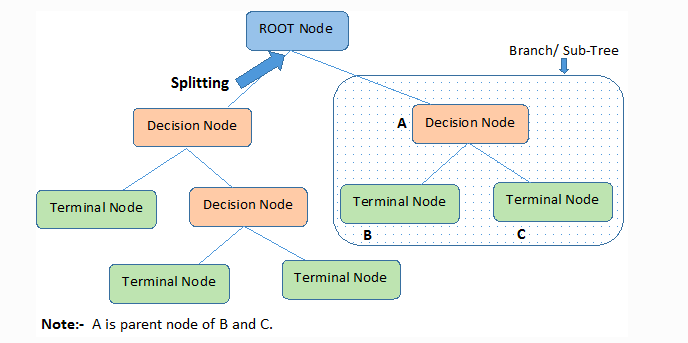
Decision trees use multiple algorithms to decide to split a node into two or more sub-nodes. The creation of sub-nodes increases the homogeneity of resultant sub-nodes. In other words, we can say that the purity of the node increases with respect to the target variable. The decision tree splits the nodes on all available variables and then selects the split which results in most homogeneous sub-nodes.

On the downside, decision trees are prone to overfitting. They can easily become over-complex which prevents them from generalizing well to the structure in the dataset. In that case, the model is likely to end up overfitting which is a serious issue in machine learning. To overcome this decision tree hyperparameters could be tuned. For a description of some parameters, refer to this
<a href="https://towardsdatascience.com/hyperparameters-of-decision-trees-explained-with-visualizations-1a6ef2f67edf" target="_BLANK">link</a>

In [21]:
from pyspark.ml.classification import DecisionTreeClassifier

# Extracts the number of nodes in the decision tree and the tree depth in the model and stores it in dt.
dt = DecisionTreeClassifier(featuresCol = 'features', labelCol = 'label', maxDepth = 3)
dtModel = dt.fit(train_data)

In [22]:
# Get predictions from the test data
dtPredictions = dtModel.transform(test_data)

# Display the predictions
dtPredictions.show()

+---+------------+-------+---------+-------+-------+-------+----+---------+---+-----+--------+--------+-----+--------+--------+-------+-----+---------+-------------+---------------+-------------+-------------+----------+-------------+-----------+--------------+--------------+---------------+-----------------+---------------+---------------+-------------+---------------+--------------+----------------+--------------------+--------------+--------------------+----------+
|age|         job|marital|education|default|balance|housing|loan|  contact|day|month|duration|campaign|pdays|previous|poutcome|deposit|label|job_index|marital_index|education_index|default_index|housing_index|loan_index|contact_index|month_index|poutcome_index|   job_encoded|marital_encoded|education_encoded|default_encoded|housing_encoded| loan_encoded|contact_encoded| month_encoded|poutcome_encoded|            features| rawPrediction|         probability|prediction|
+---+------------+-------+---------+-------+-------+--

In [23]:
dtPredictions.select(
    "label",
    "prediction",
    "probability"
).show(20, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.8226490396607633,0.17735096033923672]|
|1.0  |0.0       |[0.8226490396607633,0.17735096033923672]|
|1.0  |0.0       |[0.8226490396607633,0.17735096033923672]|
|1.0  |0.0       |[0.8226490396607633,0.17735096033923672]|
|1.0  |1.0       |[0.13541666666666666,0.8645833333333334]|
|1.0  |1.0       |[0.34897206114918294,0.6510279388508171]|
|1.0  |0.0       |[0.8226490396607633,0.17735096033923672]|
|0.0  |0.0       |[0.8226490396607633,0.17735096033923672]|
|0.0  |1.0       |[0.13541666666666666,0.8645833333333334]|
|1.0  |1.0       |[0.34897206114918294,0.6510279388508171]|
|0.0  |0.0       |[0.8226490396607633,0.17735096033923672]|
|1.0  |0.0       |[0.8226490396607633,0.17735096033923672]|
|1.0  |1.0       |[0.34897206114918294,0.6510279388508171]|
|1.0  |1.0       |[0.34897206114918294,0

<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#006DAE">NOTE: </strong>
    You can see that DecisionTree has a parameter called <code>maxDepth</code>. Discuss the significance of this parameter.
</div>

### Random Forest <a class="anchor" name="rf"></a>

In [24]:
# Implement Random Forest Classifier
from pyspark.ml.classification import RandomForestClassifier

# Create the Random Forest Classification model
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=5,
    seed=42
)

# Train the model using the training data
rfModel = rf.fit(train_data)

In [25]:
rfPredictions = rfModel.transform(test_data)

rfPredictions.select(
    "label",
    "prediction",
    "probability"
).show(20, truncate=False)


+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.633938418191339,0.366061581808661]   |
|1.0  |0.0       |[0.5869022954788042,0.4130977045211958] |
|1.0  |0.0       |[0.6598827283169775,0.3401172716830224] |
|1.0  |1.0       |[0.4727956165510844,0.5272043834489156] |
|1.0  |1.0       |[0.1745761605335238,0.8254238394664761] |
|1.0  |1.0       |[0.3690241634479624,0.6309758365520377] |
|1.0  |0.0       |[0.8061404704481692,0.19385952955183086]|
|0.0  |0.0       |[0.8314638914027518,0.1685361085972482] |
|0.0  |1.0       |[0.2572058757812072,0.7427941242187929] |
|1.0  |1.0       |[0.44467109435254193,0.5553289056474581]|
|0.0  |0.0       |[0.5850215716382082,0.41497842836179183]|
|1.0  |0.0       |[0.6085704143133932,0.3914295856866068] |
|1.0  |1.0       |[0.3181201566512227,0.6818798433487773] |
|1.0  |1.0       |[0.19080098548945737,0

### Logistic Regression <a class="anchor" name="lr"></a>
*Logistic Regression* is a classification algorithm. It is used to predict a binary outcome (1 / 0, Yes / No, True / False) given a set of independent variables. To represent binary/categorical outcome, we use dummy variables. You can also think of logistic regression as a special case of linear regression when the outcome variable is categorical, where we are using log of odds as dependent variable. In simple words, it predicts the probability of occurrence of an event by fitting data to a logit function.

In [26]:
# Implement Logistic Regression Classifier
from pyspark.ml.classification import LogisticRegression

# Create an initial Logistic Regression model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

# Train the model using the training data
lrModel = lr.fit(train_data)

In [27]:
lrPredictions = lrModel.transform(test_data)

lrPredictions.select(
    "label",
    "prediction",
    "probability"
).show(20, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.6149162086141913,0.3850837913858087] |
|1.0  |0.0       |[0.5242042979390918,0.47579570206090815]|
|1.0  |0.0       |[0.7448156316390384,0.2551843683609616] |
|1.0  |1.0       |[0.12111868788524867,0.8788813121147513]|
|1.0  |1.0       |[0.07445894406032363,0.9255410559396764]|
|1.0  |1.0       |[0.28092167527036377,0.7190783247296362]|
|1.0  |0.0       |[0.7469953581985428,0.2530046418014572] |
|0.0  |0.0       |[0.8987952433945469,0.10120475660545314]|
|0.0  |1.0       |[0.17193238386395235,0.8280676161360476]|
|1.0  |1.0       |[0.4978909979427153,0.5021090020572847] |
|0.0  |0.0       |[0.5227477483877739,0.47725225161222606]|
|1.0  |0.0       |[0.5814353139664165,0.41856468603358354]|
|1.0  |1.0       |[0.03934334683579829,0.9606566531642017]|
|1.0  |1.0       |[0.02264547478904638,0

<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#006DAE">NOTE: </strong>
    Discuss various parameters used in <code>Logistic Regression</code>.
</div>

## Model Evaluation <a class="anchor" name="model-evaluation"></a>
<hr />
Our goal is not just to build a model, it is about selecting a model which gives high accuracy on our sample data. There are different kinds of evaluation metrics, the choice of these depend on the type and implementation plan. More details on evaluation metrics for classification in Spark can be found <a href="https://spark.apache.org/docs/latest/mllib-evaluation-metrics.html" target="_BLANK">here</a>.
We are going to cover the following evaluation in this session:

<ul>
    <li>
        Confusion Matrix
        <ul>
            <li>Accuracy</li>
            <li>Precision</li>
            <li>Recall</li>
            <li>F1-Score</li>
        </ul>
    </li>
    <li>AUC-ROC</li>        
    </ul>

#### Accuracy
<span style="color:red;font-weight:bold">Accuracy is useful when the target class is well balanced but is not a good choice with unbalanced classes.</span> For example, if a model is designed to predict fraud from a dataset where 95% of the data points are not fraud and 5% of the data points are fraud, then a naive classifier that predicts not fraud, regardless of input, will be 95% accurate. For this reason, metrics like precision and recall are typically used because they take into account the type of error. In most applications there is some desired balance between precision and recall, which can be captured by combining the two into a single metric, called the F-measure.

#### Confusion Matrix <a class="anchor" name="confusion-matrix"></a>

Confusion Matrix is a performance measurement for machine learning classification problem where output can be two or more classes. It is a table with 4 different combinations of predicted and actual values as shown in the picture below where T/F refers to true and positive respectively, and P/N to positive and negative respectively.
<div>
    <div style="float:left;width:50%">
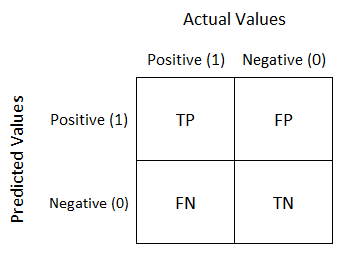
    </div>
    <div style="float:right;width:50%;padding-top:50px">
    <img src="https://miro.medium.com/max/1400/1*UVP_xb4F6J-M-xH3haz5Jw.png">
    </div>
    <div style="clear:both"></div>
    </div>

From the confusion matrix, we can obtain the following indicators.

- **Recall:** Out of all the positive classes, how much we predicted correctly. It should be high as possible.
- **Precision:** Out of all the positive classes we have predicted correctly, how many are actually positive.
- **Accuracy:** Out of all the classes, how much we predicted correctly. It should be high as possible.
- **F1-Score : Combining Precision and Accuracy:** It is the weighted average of Precision and Recall. It takes both <strong>False Positives</strong> and <strong>False Negative </strong> into account.

<a class="anchor" id="lab-task-2"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#FF5555">2. Lab Task: </strong>
    Calculate the remaining <strong>False Negative and False Positive</strong> for <code>Decision Tree</code> based on the example below. Then Compute the other metrics, i.e. <strong>Accuracy</strong>, <strong>Precision</strong>, <strong>Recall</strong> and <strong>F1-Score</strong> for the DT Model.    
    
<strong style="color:orange">NOTE:</strong>In our case we are using Yes=1 and No=0. Remember that 1 doesn't mean positive always, it will depend on how the Target variable is encoded as well.
</div>


In [28]:
# Calculate the elements of the confusion matrix
TN = dtPredictions.filter('prediction = 0 AND label = 0').count()
TP = dtPredictions.filter('prediction = 1 AND label = 1').count()

FN = dtPredictions.filter('prediction = 0 AND label = 1').count()
FP = dtPredictions.filter('prediction = 1 AND label = 0').count()

# Show confusion matrix
dtPredictions.groupBy('label', 'prediction').count().show()

# Calculate metrics by the confusion matrix
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1 = 2 * (precision * recall) / (precision + recall)

# Display the various metrics
print("True Negatives (TN):", TN)
print("True Positives (TP):", TP)
print("False Negatives (FN):", FN)
print("False Positives (FP):", FP)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0|  780|
|  0.0|       1.0|  284|
|  1.0|       0.0|  233|
|  0.0|       0.0|  867|
+-----+----------+-----+

True Negatives (TN): 867
True Positives (TP): 780
False Negatives (FN): 233
False Positives (FP): 284

Accuracy: 0.761090573012939
Precision: 0.7330827067669173
Recall: 0.769990128331688
F1-score: 0.7510832932113626


<a class="anchor" id="lab-task-3"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#FF5555">3. Lab Task: </strong>
    Create a function <code>compute_metrics()</code> which takes <strong>predictions</strong> as input parameter and computes all these metrics. Use the function to compute the 4 metrics for all 3 Classification Algorithms.
</div>


In [29]:
def compute_metrics(predictions):
    
    # Calculate confusion matrix elements
    TN = predictions.filter('prediction = 0 AND label = 0').count()
    TP = predictions.filter('prediction = 1 AND label = 1').count()
    FN = predictions.filter('prediction = 0 AND label = 1').count()
    FP = predictions.filter('prediction = 1 AND label = 0').count()
    
    # Calculate metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = 2 * (precision * recall) / (precision + recall)
    
    return accuracy, precision, recall, f1

In [32]:
#WRITE CODE : Print the accuracy,precision,recall and f1 scores for each Classification algorithm, using the function created

# Decision Tree predictions
dtPredictions = dtModel.transform(test_data)

# Random Forest predictions
rfPredictions = rfModel.transform(test_data)

# Logistic Regression predictions
lrPredictions = lrModel.transform(test_data)

# Calculate metrics for each classification algorithm
dt_metrics = compute_metrics(dtPredictions)
rf_metrics = compute_metrics(rfPredictions)
lr_metrics = compute_metrics(lrPredictions)


print("Decision Tree:")
print("Accuracy:", dt_metrics[0])
print("Precision:", dt_metrics[1])
print("Recall:", dt_metrics[2])
print("F1-score:", dt_metrics[3])

print("\nRandom Forest:")
print("Accuracy:", rf_metrics[0])
print("Precision:", rf_metrics[1])
print("Recall:", rf_metrics[2])
print("F1-score:", rf_metrics[3])

print("\nLogistic Regression:")
print("Accuracy:", lr_metrics[0])
print("Precision:", lr_metrics[1])
print("Recall:", lr_metrics[2])
print("F1-score:", lr_metrics[3])

Decision Tree:
Accuracy: 0.761090573012939
Precision: 0.7330827067669173
Recall: 0.769990128331688
F1-score: 0.7510832932113626

Random Forest:
Accuracy: 0.8036044362292052
Precision: 0.7805343511450382
Recall: 0.807502467917078
F1-score: 0.7937894226103834

Logistic Regression:
Accuracy: 0.8105360443622921
Precision: 0.8105046343975283
Recall: 0.7769002961500494
F1-score: 0.7933467741935484


<a class="anchor" id="lab-task-4"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#FF5555">4. Lab Task: </strong>
  Present the accuracies, precision and recall of the different classification algorithms in a bar chart using <code>matplotlib</code>.  You can use the function given here:
    <pre>
    import matplotlib.pyplot as plt
    %matplotlib inline
    def plot_metrics(x,y):
        plt.style.use('ggplot')   
        x_pos = [i for i, _ in enumerate(x)]
        plt.bar(x_pos, y, color='blue')
        plt.xlabel("Classification Algorithms")
        plt.ylabel("AUC")
        plt.title("Accuracy of ML Classification Algorithms")
        plt.xticks(x_pos, x)
        plt.show()
    </pre>
What do you observe about the differences in the accuracy/precision/recall/f1-scores for these different classification algorithms? How do you decide the most suitable metric? Discuss this with your tutor.   
</div>


In [35]:
dt_accuracy, dt_precision, dt_recall, dt_f1 = compute_metrics(dtPredictions)
rf_accuracy, rf_precision, rf_recall, rf_f1 = compute_metrics(rfPredictions)
lr_accuracy, lr_precision, lr_recall, lr_f1 = compute_metrics(lrPredictions)

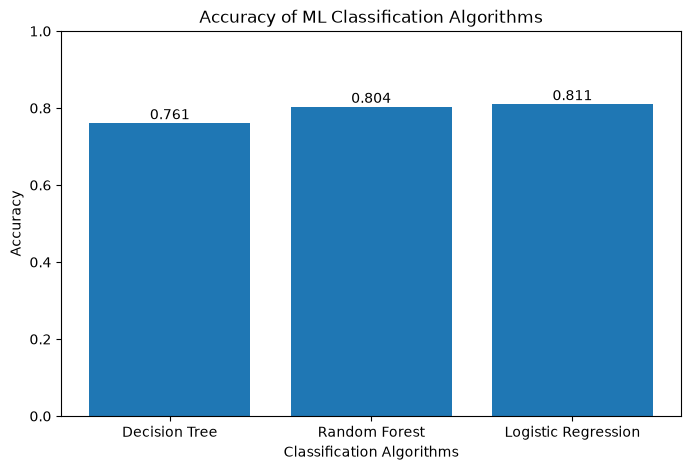

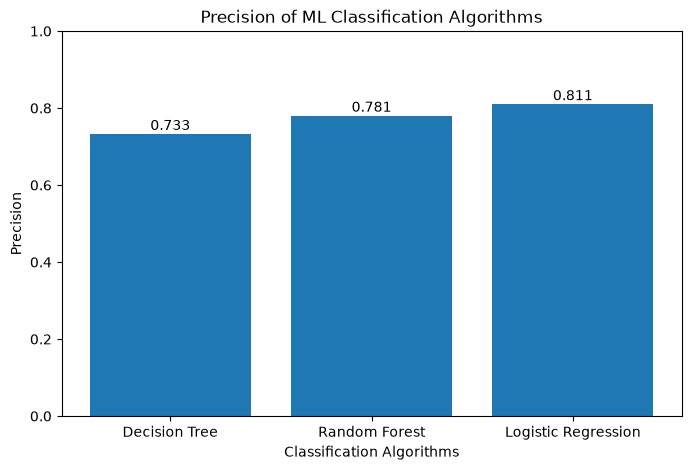

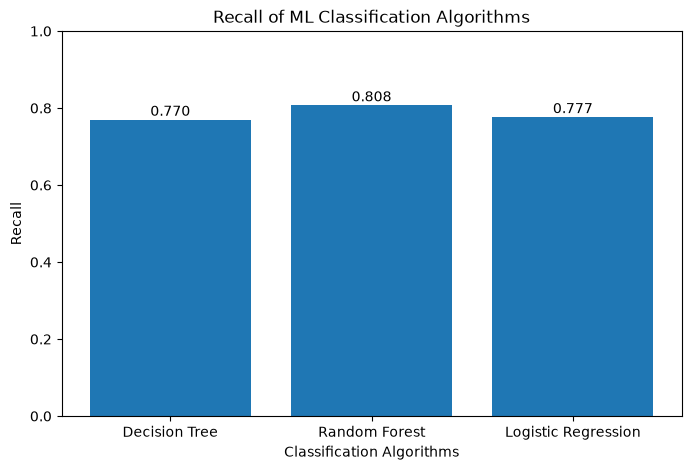

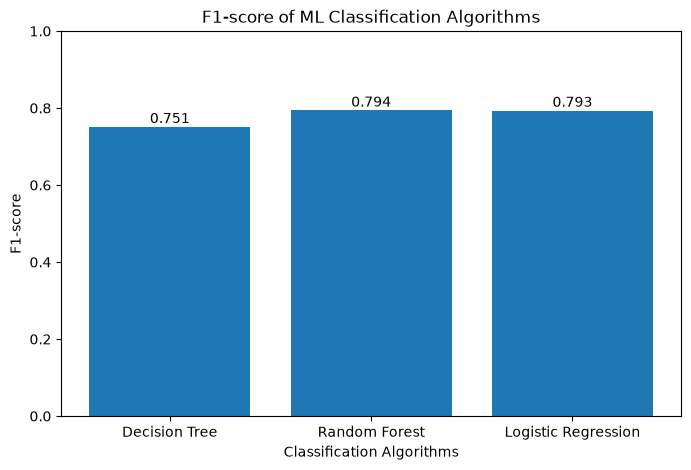

In [36]:
import matplotlib.pyplot as plt

%matplotlib inline

algorithms = [
    "Decision Tree",
    "Random Forest",
    "Logistic Regression"
]

def plot_metrics(x, y, metric_name):
    x_pos = [i for i, _ in enumerate(x)]
    
    plt.figure(figsize=(8, 5))
    plt.bar(x_pos, y)
    
    plt.xlabel("Classification Algorithms")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} of ML Classification Algorithms")
    plt.xticks(x_pos, x)
    plt.ylim(0, 1)
    
    for i, value in enumerate(y):
        plt.text(
            i,
            value + 0.01,
            f"{value:.3f}",
            ha="center"
        )
    
    plt.show()


# Accuracy
plot_metrics(
    algorithms,
    [dt_accuracy, rf_accuracy, lr_accuracy],
    "Accuracy"
)

# Precision
plot_metrics(
    algorithms,
    [dt_precision, rf_precision, lr_precision],
    "Precision"
)

# Recall
plot_metrics(
    algorithms,
    [dt_recall, rf_recall, lr_recall],
    "Recall"
)

# F1-score
plot_metrics(
    algorithms,
    [dt_f1, rf_f1, lr_f1],
    "F1-score"
)

#### Area Under the Curve (AUC-ROC) <a class="anchor" name="roc"></a>
When we need to check or visualize the performance of the multi - class classification problem, we use AUC (Area Under The Curve) ROC (Receiver Operating Characteristics) curve. It is one of the most important evaluation metrics for checking any classification model’s performance.

<br/><br/>

<div style="width:40%;float:left;text-align:left;">
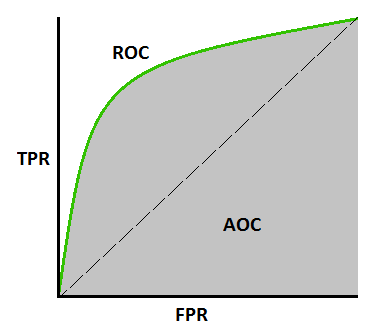
    </div><div style="width:60%;float:right;text-align:justify">
AUC - ROC curve is a performance measurement for classification problem at various thresholds settings. ROC is a probability curve and AUC represents degree or measure of separability. It tells how much model is capable of distinguishing between classes. Higher the AUC, better the model is at predicting 0s as 0s and 1s as 1s.
    
In the example below, we are using Spark's <code>BinaryClassificationEvaluator</code> to compute the AUC-ROC curve.
   </div>
   <div style="clear:both"></div> 

##### Binary Classification Metrics <a class="anchor" name="bce"></a> 
Now let's evaluate the model using BinaryClassificationMetrics class in Spark ML. BinaryClassificationMetrics by default uses areaUnderROC as the performance metric.
<a href="https://spark.apache.org/docs/latest/mllib-evaluation-metrics.html#binary-classification" target='_BLANK'>Read More</a>

<a class="anchor" id="lab-task-5"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#FF5555">5. Lab Task: </strong>
    Compute the <code>Area Under ROC</code> for the two other Algorithms based on the example below.
</div>


In [37]:
# Use BinaryClassificationEvaluator to evaluate a model
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Evaluate model Decision Tree
evaluator = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
auc_dt = evaluator.evaluate(dtPredictions)
print(auc_dt)
print(evaluator.getMetricName())

0.7189198971150885
areaUnderROC


In [38]:
#WRITE CODE : area under curve for Random Forest
auc_rf = evaluator.evaluate(rfPredictions)

print("Random Forest AUC:", auc_rf)
print(evaluator.getMetricName())

Random Forest AUC: 0.8824396657526872
areaUnderROC


In [39]:
#WRITE CODE : area under curve for Logistic Regression

auc_lr = evaluator.evaluate(lrPredictions)

print("Logistic Regression AUC:", auc_lr)
print(evaluator.getMetricName())

Logistic Regression AUC: 0.8916204888148285
areaUnderROC


In [40]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Create evaluator
evaluator = BinaryClassificationEvaluator(
    rawPredictionCol="rawPrediction"
)

# Decision Tree
auc_dt = evaluator.evaluate(dtPredictions)

# Random Forest
auc_rf = evaluator.evaluate(rfPredictions)

# Logistic Regression
auc_lr = evaluator.evaluate(lrPredictions)

# Display results
print("Decision Tree AUC:", auc_dt)
print("Random Forest AUC:", auc_rf)
print("Logistic Regression AUC:", auc_lr)

print("\nMetric used:", evaluator.getMetricName())

Decision Tree AUC: 0.7189198971150885
Random Forest AUC: 0.8824396657526872
Logistic Regression AUC: 0.8916204888148285

Metric used: areaUnderROC


### Visualizing AUC-ROC <a class="anchor" name="roc-viz"></a> 
We can easily visualize the ROC curve for <strong>Logistic Regression</strong> using the <code>BinaryClassificationEvaluator</code>. The example below shows how to plot it using matplotlib.


Area Under ROC: 0.8916204888148285


/opt/anaconda3/envs/ITO5202/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


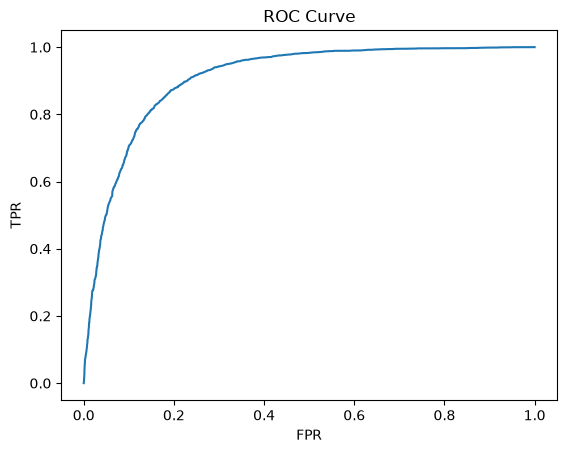

In [41]:
import matplotlib.pyplot as plt

print("Area Under ROC: " + str(evaluator.evaluate(lrPredictions, {evaluator.metricName: "areaUnderROC"})))

# Plot ROC curve
trainingSummary = lrModel.summary
roc = trainingSummary.roc.toPandas()
plt.plot(roc['FPR'],roc['TPR'])
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.title('ROC Curve')
plt.show()

<div style="background:rgba(164,0,255,0.2);padding:10px;border-radius:4px">
However, for other algorithms, we need to calculate it manually. The ROC Curve is simply a line plot of <code>FPR</code> and <code>TPR</code> across all thresholds (i.e. 0-1). We can calculate <code>TPR</code> and <code>FPR</code> from the confusion matrix. However, by default, a threshold value of 0.5 is used while computing the confusion matrix. So we need a way to compute the confusion matrix for different thresholds.</div>

##### Getting the thresholds
We can simply use numpy <code>linspace</code> to get a list of thresholds.

In [49]:
import numpy as np
print(np.linspace(0, 1, 100))

[0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919 0.2020202  0.21212121 0.22222222 0.23232323
 0.24242424 0.25252525 0.26262626 0.27272727 0.28282828 0.29292929
 0.3030303  0.31313131 0.32323232 0.33333333 0.34343434 0.35353535
 0.36363636 0.37373737 0.38383838 0.39393939 0.4040404  0.41414141
 0.42424242 0.43434343 0.44444444 0.45454545 0.46464646 0.47474747
 0.48484848 0.49494949 0.50505051 0.51515152 0.52525253 0.53535354
 0.54545455 0.55555556 0.56565657 0.57575758 0.58585859 0.5959596
 0.60606061 0.61616162 0.62626263 0.63636364 0.64646465 0.65656566
 0.66666667 0.67676768 0.68686869 0.6969697  0.70707071 0.71717172
 0.72727273 0.73737374 0.74747475 0.75757576 0.76767677 0.77777778
 0.78787879 0.7979798  0.80808081 0.81818182 0.82828283 0.83838384
 0.84848485 0.85858586 0.86868687 0.87878788 0.88888889 0.89898

If we look at the <code>probability</code> column of the predictions, we will see it is an <code>Array</code> with two probability values, the first one for negative class and the second one for positive class. Now we can consider the <strong>probability for positive class</strong> to decide which value is <strong>positive</strong> and which value is <strong>negative</strong>

For example, if our threshold is 0.7, we can say <strong>if the positive probability is greater than 0.7, it is a positive prediction else it is a negative prediction</strong>. 

Here is an example for the Decision Tree Predictions.

In [50]:
#User Defined Function to split the probabilities into two columns
import pyspark.sql.functions as F
import pyspark.sql.types as T
to_array = F.udf(lambda v: v.toArray().tolist(), T.ArrayType(T.FloatType()))

/opt/anaconda3/envs/ITO5202/lib/python3.13/site-packages/pyspark/sql/udf.py:116: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [51]:
#Splitting the probability to 2 parts using the UDF
df = dtPredictions.withColumn('probability', to_array('probability'))

In [52]:
#A new df which contains the probabilites in separate columns
prob_df = df.select(df.probability[0].alias('negative_prob'),df.probability[1].alias('positive_prob'),'label')

Now, we have extracted the probabilities for positive and negative class. Now we need to create our own <code>prediction</code> column based on a threshold we are provided.

In [53]:
#Here based on the threshold, the prediction column is computed
threshold=0.7
prob_df.withColumn('prediction',F.when(prob_df.positive_prob > threshold,1).otherwise(0))

DataFrame[negative_prob: float, positive_prob: float, label: double, prediction: int]

Now we can create the confusion metrics based on the new predicted class. Let's create a function to do that. The function returns the TN,TP,FN and FP values.

CHALLENGE TASK: the following confusion_matrix function is slow, why is it so slow? Can you refactor it?

In [54]:
def confusion_matrix(predictions):
     # Calculate the elements of the confusion matrix
    TN = predictions.filter('prediction = 0 AND label = 0').count()
    TP = predictions.filter('prediction = 1 AND label = 1').count()
    FN = predictions.filter('prediction = 0 AND label = 1').count()
    FP = predictions.filter('prediction = 1 AND label = 0').count()
    return TP,TN,FP,FN

In [55]:
#TESTING 
#for threshold 0.7, lets calculate the TN,TP,FN,FP from confusion matrix
threshold=0.7
test_df=prob_df.withColumn('prediction',F.when(prob_df.positive_prob > threshold,1).otherwise(0))
tp,tn,fp,fn = confusion_matrix(prob_df)  
tpr = tp/(tp+fn)
fpr = fp/(fp+tn)
print('TPR:',tpr,'FPR:',fpr)

TPR: 0.769990128331688 FPR: 0.2467419635099913


<a class="anchor" id="challenge-task"></a>
<div style="background:rgba(164,0,255,0.2);padding:10px;border-radius:4px"><strong style="color:purple">CHALLENGE TASK: </strong>
    Based on all the above information, create a function, which loops through all the thresholds and computes the <code>TPR</code> and <code>TFR</code> for each threshold. Store all the <code>TPR</code> and <code>TFR</code> values in separate arrays and later visualize the <strong>ROC Curve</strong> for <strong>Decision Tree</strong> and <strong>Random Forest</strong>.
</div>


In [ ]:
#WRITE CODE 

### Congratulations on finishing this activity. See you next week.

## References

1. https://www.kdnuggets.com/2020/04/performance-evaluation-metrics-classification.html
2. https://spark.apache.org/docs/latest/mllib-evaluation-metrics.html